In [1]:
!pip install langgraph
!pip install nbconvert[web pdf]

  Using cached langchain_core-1.4.0-py3-none-any.whl.metadata (4.5 kB)
Using cached langchain_core-1.4.0-py3-none-any.whl (548 kB)
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.86
    Uninstalling langchain-core-0.3.86:
      Successfully uninstalled langchain-core-0.3.86


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.3.25 requires langchain-core<1.0.0,>=0.3.58, but you have langchain-core 1.4.0 which is incompatible.
langchain-classic 1.0.4 requires langchain-text-splitters<2.0.0,>=1.1.2, but you have langchain-text-splitters 0.3.11 which is incompatible.
langchain-community 0.3.23 requires langchain-core<1.0.0,>=0.3.56, but you have langchain-core 1.4.0 which is incompatible.
langchain-groq 0.3.2 requires langchain-core<1.0.0,>=0.3.49, but you have langchain-core 1.4.0 which is incompatible.
ERROR: Invalid requirement: 'nbconvert[web': Expected matching RIGHT_BRACKET for LEFT_BRACKET, after extras
    nbconvert[web
             ~~~~^


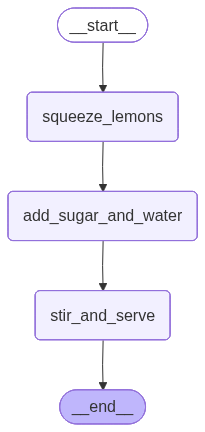

In [2]:
from langgraph.graph import StateGraph
from typing import Dict, Any
from IPython.display import Image, display

# Define nodes
def squeeze_lemons(state: Dict[str, Any]) -> Dict[str, Any]:
    state["juice"] = f"Juice from {state.get('lemons', 0)} lemons"
    return state

def add_sugar_and_water(state: Dict[str, Any]) -> Dict[str, Any]:
    state["mix"] = f"{state['juice']} + {state.get('sugar', 0)} spoons sugar + {state.get('water', '')} water"
    return state

def stir_and_serve(state: Dict[str, Any]) -> Dict[str, Any]:
    state["final"] = f"{state['mix']} → Stirred and ready to serve!"
    return state

from typing import TypedDict

class LemonState(TypedDict):
    lemons: int
    sugar: int
    water: str
    juice: str
    mix: str
    final: str


# Build graph
builder = StateGraph(LemonState)
builder.add_node("squeeze_lemons", squeeze_lemons)
builder.add_node("add_sugar_and_water", add_sugar_and_water)
builder.add_node("stir_and_serve", stir_and_serve)

builder.set_entry_point("squeeze_lemons")
builder.add_edge("squeeze_lemons", "add_sugar_and_water")
builder.add_edge("add_sugar_and_water", "stir_and_serve")
builder.set_finish_point("stir_and_serve")

graph = builder.compile()

# ✅ Visualize as Mermaid PNG
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Visualization failed. Ensure Mermaid & pygraphviz dependencies are installed.")
    print(f"Error: {e}")


In [3]:
# Initial input state
initial_state: LemonState = {
    "lemons": 4,
    "sugar": 2,
    "water": "1 glass",
    "juice": "",
    "mix": "",
    "final": ""
}

# Run the LangGraph
result = graph.invoke(initial_state)

# Print final result
print("🧃 Final Output:", result["final"])


🧃 Final Output: Juice from 4 lemons + 2 spoons sugar + 1 glass water → Stirred and ready to serve!
